<a href="https://colab.research.google.com/github/contactyuvrajchand-droid/machine_learning_lab/blob/main/Week_5_Multiclass_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install PySpark in Google Colab
!pip install -q pyspark

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import libraries and create Spark session
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, trim, when, isnan

from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer,
    OneHotEncoder,
    VectorAssembler,
    Imputer,
    StandardScaler,
    IndexToString
)

from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Start the Spark session
spark = SparkSession.builder \
    .appName("Customer Segmentation Multiclass Classification") \
    .getOrCreate()

print("Spark session started successfully.")

Spark session started successfully.


In [ ]:
#Load the customer segmentation dataset
dataset_path = '/content/drive/MyDrive/Colab Notebooks/lab5/customer_segmentation_dataset.csv'

dff = spark.read.csv(
    dataset_path,
    inferSchema=True,
    header=True
)

In [ ]:
print(dff.count())

2000000


In [ ]:
dff.select("customer_segment").distinct().show()
dff.printSchema()

+----------------+
|customer_segment|
+----------------+
|    Medium Value|
|      High Value|
|       Low Value|
+----------------+

root
 |-- age: integer (nullable = true)
 |-- annual_income: integer (nullable = true)
 |-- spending_score: integer (nullable = true)
 |-- years_as_customer: integer (nullable = true)
 |-- number_of_purchases: integer (nullable = true)
 |-- customer_segment: string (nullable = true)



In [ ]:
# Check whether classes are balanced
dff.groupBy("customer_segment").count().orderBy("customer_segment").show()

+----------------+-------+
|customer_segment|  count|
+----------------+-------+
|      High Value| 485871|
|       Low Value|1008881|
|    Medium Value| 505248|
+----------------+-------+



In [ ]:
# Checking distinct values in all string columns
for column_name, data_type in dff.dtypes:

    if data_type == "string":

        print("Column name:", column_name)

        dff.select(column_name) \
            .distinct() \
            .show(truncate=False)

Column name: customer_segment
+----------------+
|customer_segment|
+----------------+
|Medium Value    |
|High Value      |
|Low Value       |
+----------------+



In [ ]:
# Take only numerical features
numeric_features = [
    column_name
    for column_name, data_type in dff.dtypes
    if data_type in [
        "int",
        "bigint",
        "double",
        "float",
        "smallint",
        "tinyint",
        "long"
    ]
]

dff.select(numeric_features) \
    .describe() \
    .toPandas() \
    .transpose()

,0,1,2,3,4
summary,count,mean,stddev,min,max
age,2000000,43.477824,15.00015569010386,18,69
annual_income,2000000,85001.7181955,37527.92677419766,20000,149999
spending_score,2000000,50.049344,28.567160870674087,1,99
years_as_customer,2000000,9.987763,5.478078153924148,1,19
number_of_purchases,2000000,25.019448,14.143843812749502,1,49


In [ ]:
# Find whether any column contains null values
print("Total records:", dff.count())

for column_name in dff.columns:

    null_count = dff.where(
        dff[column_name].isNull()
    ).count()

    print(
        column_name,
        "Total null values:",
        null_count
    )

Total records: 2000000
age Total null values: 0
annual_income Total null values: 0
spending_score Total null values: 0
years_as_customer Total null values: 0
number_of_purchases Total null values: 0
customer_segment Total null values: 0


In [ ]:
# Do not use ID columns as model features
id_columns = [
    "id",
    "customer_id",
    "customerid"
]

# Select all numerical columns except possible ID columns
numericCols = [
    column_name
    for column_name in numeric_features
    if column_name.lower() not in id_columns
]

print("Numerical features used:")
print(numericCols)

# Select input features and output column
df = dff.select(
    *(numericCols + ["customer_segment"])
)

cols = df.columns

df.printSchema()

Numerical features used:
['age', 'annual_income', 'spending_score', 'years_as_customer', 'number_of_purchases']
root
 |-- age: integer (nullable = true)
 |-- annual_income: integer (nullable = true)
 |-- spending_score: integer (nullable = true)
 |-- years_as_customer: integer (nullable = true)
 |-- number_of_purchases: integer (nullable = true)
 |-- customer_segment: string (nullable = true)



In [ ]:
# Remove null records to prevent VectorAssembler errors
df = df.na.drop()

print("Total records after removing null values:", df.count())

Total records after removing null values: 2000000


In [ ]:
# Create label and feature vector
from pyspark.ml.feature import StringIndexer, VectorAssembler

stages = []

# Convert customer segment classes into numerical labels
label_stringIdx = StringIndexer(
    inputCol="customer_segment",
    outputCol="label"
)

print(label_stringIdx)

stages += [label_stringIdx]

# Combine all numerical columns into one feature vector
assembler = VectorAssembler(
    inputCols=numericCols,
    outputCol="features"
)

stages += [assembler]

StringIndexer_17fe4ba04ed6


In [ ]:
# Apply the pipeline
from pyspark.ml import Pipeline

pipeline = Pipeline(stages=stages)

pipelineModel = pipeline.fit(df)

df = pipelineModel.transform(df)

df.show(12, True)

+---+-------------+--------------+-----------------+-------------------+----------------+-----+--------------------+
|age|annual_income|spending_score|years_as_customer|number_of_purchases|customer_segment|label|            features|
+---+-------------+--------------+-----------------+-------------------+----------------+-----+--------------------+
| 22|       113441|            19|                2|                 44|       Low Value|  0.0|[22.0,113441.0,19...|
| 47|        85415|            74|                7|                 11|    Medium Value|  1.0|[47.0,85415.0,74....|
| 60|        78075|            18|               19|                 37|       Low Value|  0.0|[60.0,78075.0,18....|
| 44|        89388|            84|               10|                 15|      High Value|  2.0|[44.0,89388.0,84....|
| 37|        94910|            85|               15|                 31|      High Value|  2.0|[37.0,94910.0,85....|
| 29|        83134|            64|               12|            

In [ ]:
# Display feature vector
print(df.select("features").show(1))

print(cols)

+--------------------+
|            features|
+--------------------+
|[22.0,113441.0,19...|
+--------------------+
only showing top 1 row
None
['age', 'annual_income', 'spending_score', 'years_as_customer', 'number_of_purchases', 'customer_segment']


In [ ]:
# Show the numerical label assigned to each customer segment
label_model = pipelineModel.stages[0]

print("Customer segment label mapping:")

for label_number, segment_name in enumerate(label_model.labels):

    print(
        label_number,
        "=",
        segment_name
    )

Customer segment label mapping:
0 = Low Value
1 = Medium Value
2 = High Value


In [ ]:
# Feature vector is stored in the features column
selectedCols = ['label', 'features'] + cols

dfSelected = df.select(selectedCols)

dfSelected.printSchema()

root
 |-- label: double (nullable = false)
 |-- features: vector (nullable = true)
 |-- age: integer (nullable = true)
 |-- annual_income: integer (nullable = true)
 |-- spending_score: integer (nullable = true)
 |-- years_as_customer: integer (nullable = true)
 |-- number_of_purchases: integer (nullable = true)
 |-- customer_segment: string (nullable = true)



In [ ]:
# Multinomial classification using Logistic Regression

from pyspark.ml.classification import LogisticRegression

# Split dataset into training and testing sets
train, test = dfSelected.randomSplit(
    [0.7, 0.3],
    seed=2018
)

print("Training Dataset Count:", train.count())
print("Test Dataset Count:", test.count())

from pyspark.ml.classification import LogisticRegression

# Create a true Multinomial Logistic Regression model
multinomial_lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    family="multinomial",
    maxIter=100
)

# Train the model
multinomialModel = multinomial_lr.fit(train)

# Make predictions
predictions_lr = multinomialModel.transform(test)

predictions_lr.show(10)

Training Dataset Count: 1400225
Test Dataset Count: 599775
+-----+--------------------+---+-------------+--------------+-----------------+-------------------+----------------+--------------------+--------------------+----------+
|label|            features|age|annual_income|spending_score|years_as_customer|number_of_purchases|customer_segment|       rawPrediction|         probability|prediction|
+-----+--------------------+---+-------------+--------------+-----------------+-------------------+----------------+--------------------+--------------------+----------+
|  0.0|[18.0,20000.0,5.0...| 18|        20000|             5|               14|                 15|       Low Value|[1661.26735812034...|       [1.0,0.0,0.0]|       0.0|
|  0.0|[18.0,20077.0,38....| 18|        20077|            38|               12|                 41|       Low Value|[639.581635691057...|[1.0,2.1540412711...|       0.0|
|  0.0|[18.0,20090.0,40....| 18|        20090|            40|                4|            

In [ ]:
# Display Multinomial Logistic Regression predictions
predictions_lr.select(
    "customer_segment",
    "label",
    "rawPrediction",
    "probability",
    "prediction"
).show(10, truncate=False)

+----------------+-----+----------------------------------------------------------+---------------------------------+----------+
|customer_segment|label|rawPrediction                                             |probability                      |prediction|
+----------------+-----+----------------------------------------------------------+---------------------------------+----------+
|Low Value       |0.0  |[1661.267358120341,238.38194980211165,-1899.6493079224524]|[1.0,0.0,0.0]                    |0.0       |
|Low Value       |0.0  |[639.5816356910573,248.90951562086696,-888.4911513119241] |[1.0,2.154041271171623E-170,0.0] |0.0       |
|Low Value       |0.0  |[577.9025056240375,249.2185321192888,-827.121037743326]   |[1.0,1.7962385668848384E-143,0.0]|0.0       |
|Low Value       |0.0  |[670.5800523851028,248.34208253368067,-918.9221349187833] |[1.0,4.2109457218336146E-184,0.0]|0.0       |
|Low Value       |0.0  |[423.1394961851533,250.72977465773369,-673.8692708428869] |[1.0,1.3286460

Predicted     0.0     1.0     2.0
Actual                           
0.0        302544       0       0
1.0             0  151045       0
2.0             0       0  146186


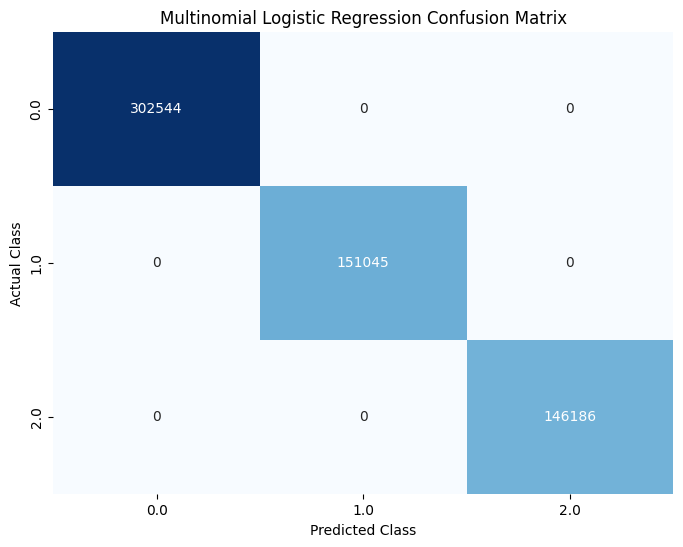

Multinomial Logistic Regression accuracy = 1.0
Accuracy percentage = 100.0 %


In [ ]:
# Multinomial Logistic Regression confusion matrix and accuracy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert predictions into a Pandas DataFrame
prediction_and_labels = predictions_lr.select(
    "prediction",
    "label"
).toPandas()

# Create the confusion matrix
confusion_matrix = pd.crosstab(
    prediction_and_labels["label"],
    prediction_and_labels["prediction"],
    rownames=["Actual"],
    colnames=["Predicted"]
)

# Display the confusion matrix
print(confusion_matrix)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Multinomial Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

# Evaluate Multinomial model accuracy
evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = evaluator.evaluate(predictions_lr)

print("Multinomial Logistic Regression accuracy =", accuracy)
print("Accuracy percentage =", accuracy * 100, "%")

In [ ]:
# Multinomial Logistic Regression F1 score
f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

f1_score = f1_evaluator.evaluate(predictions_lr)

print("Multinomial Logistic Regression F1 score =", f1_score)

Multinomial Logistic Regression F1 score = 1.0


In [ ]:
# Decision Tree Classifier

from pyspark.ml.classification import DecisionTreeClassifier

# Create the Decision Tree model
dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="label",
    maxDepth=5
)

# Train the model
dtModel = dt.fit(train)

# Make predictions
predictions_dt = dtModel.transform(test)

predictions_dt.select(
    "customer_segment",
    "label",
    "rawPrediction",
    "prediction",
    "probability"
).show(10, truncate=False)

+----------------+-----+------------------+----------+-------------+
|customer_segment|label|rawPrediction     |prediction|probability  |
+----------------+-----+------------------+----------+-------------+
|Low Value       |0.0  |[706337.0,0.0,0.0]|0.0       |[1.0,0.0,0.0]|
|Low Value       |0.0  |[706337.0,0.0,0.0]|0.0       |[1.0,0.0,0.0]|
|Low Value       |0.0  |[706337.0,0.0,0.0]|0.0       |[1.0,0.0,0.0]|
|Low Value       |0.0  |[706337.0,0.0,0.0]|0.0       |[1.0,0.0,0.0]|
|Low Value       |0.0  |[706337.0,0.0,0.0]|0.0       |[1.0,0.0,0.0]|
|Low Value       |0.0  |[706337.0,0.0,0.0]|0.0       |[1.0,0.0,0.0]|
|Low Value       |0.0  |[706337.0,0.0,0.0]|0.0       |[1.0,0.0,0.0]|
|Low Value       |0.0  |[706337.0,0.0,0.0]|0.0       |[1.0,0.0,0.0]|
|Low Value       |0.0  |[706337.0,0.0,0.0]|0.0       |[1.0,0.0,0.0]|
|Low Value       |0.0  |[706337.0,0.0,0.0]|0.0       |[1.0,0.0,0.0]|
+----------------+-----+------------------+----------+-------------+
only showing top 10 rows


Predicted     0.0     1.0     2.0
Actual                           
0.0        302544       0       0
1.0             0  151045       0
2.0             0       0  146186


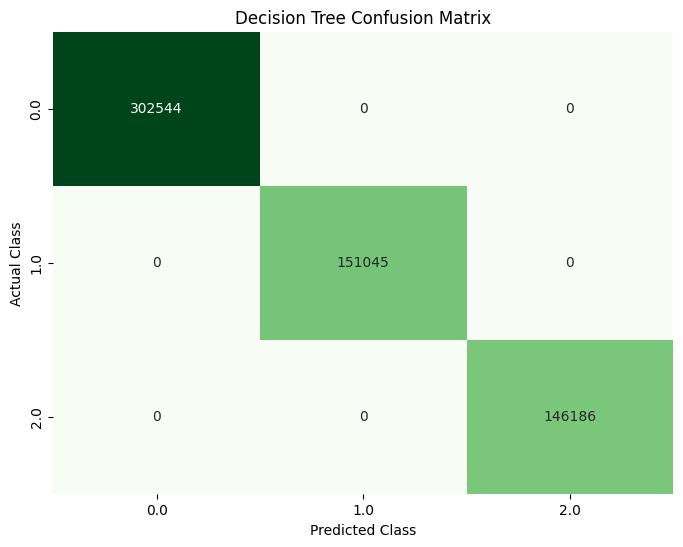

In [ ]:
# Decision Tree confusion matrix

# Convert predictions into a Pandas DataFrame
dt_prediction_and_labels = predictions_dt.select(
    "prediction",
    "label"
).toPandas()

# Create the confusion matrix
dt_confusion_matrix = pd.crosstab(
    dt_prediction_and_labels["label"],
    dt_prediction_and_labels["prediction"],
    rownames=["Actual"],
    colnames=["Predicted"]
)

# Display the confusion matrix
print(dt_confusion_matrix)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    dt_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [ ]:
# Decision Tree accuracy
dt_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

dt_accuracy = dt_evaluator.evaluate(predictions_dt)

print("Decision Tree accuracy =", dt_accuracy)
print("Accuracy percentage =", dt_accuracy * 100, "%")

Decision Tree accuracy = 1.0
Accuracy percentage = 100.0 %


In [ ]:
# Compare both models
print("Model Comparison")
print("------------------------------")
print("Multinomial Regression Accuracy:", accuracy)
print("Decision Tree Accuracy:", dt_accuracy)

if accuracy > dt_accuracy:
    print("Multinomial Logistic Regression performed better.")
elif dt_accuracy > accuracy:
    print("Decision Tree performed better.")
else:
    print("Both models produced the same accuracy.")

Model Comparison
------------------------------
Multinomial Regression Accuracy: 1.0
Decision Tree Accuracy: 1.0
Both models produced the same accuracy.
